In [ ]:
# ==========================================
# 1. SETUP (Load Data for this Notebook)
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

# Load Data
try:
    df = pd.read_csv('201 Bills and Payments.csv')
    pc = pd.read_csv('All Encounters 2026-01-01 17_20_08.csv')
    charges = pd.read_csv('260106 Charges Report.csv')
    print("Data Loaded.")
except FileNotFoundError:
    print("Error: Files not found.")


# --- QUICK RECALCULATION OF REALIZATION RATE ---
# (We need this to value the clinical visits accurately)
def clean_currency(x):
    if isinstance(x, str):
        x = x.replace('$', '').replace(',', '').strip()
        if '(' in x and ')' in x: x = '-' + x.replace('(', '').replace(')', '')
    return pd.to_numeric(x, errors='coerce')


charges['Service Charge Amount'] = charges['Service Charge Amount'].apply(clean_currency).fillna(0)
charges['Total_Contract_Adj'] = (
        charges['Pri Ins Insurance Contract Adjustment'].apply(clean_currency).fillna(0) +
        charges['Sec Ins Insurance Contract Adjustment'].apply(clean_currency).fillna(0) +
        charges['Other Ins Insurance Contract Adjustment'].apply(clean_currency).fillna(0)
)
charges['Calculated_Allowed'] = charges['Service Charge Amount'] - charges['Total_Contract_Adj']

total_billed = charges['Service Charge Amount'].sum()
total_allowed = charges['Calculated_Allowed'].sum()
REALIZATION_FACTOR = (total_allowed / total_billed) if total_billed > 0 else 0.40

print(f"Using Realization Rate: {REALIZATION_FACTOR * 100:.2f}%")

# ==========================================
# 1B. DATA CLEANING: FUTURE DATE FIXER (CORRECTED)
# ==========================================
def fix_future_dates(df, date_cols):
    """
    Scans date columns for entries in the future.
    Fixes them by setting the year to the current year.
    If that is STILL in the future, sets it to the previous year.
    """
    # 1. Define 'Today' using Pandas (Avoids datetime import errors)
    today = pd.Timestamp.now().normalize()
    current_year = today.year

    # 2. Iterate through columns
    for col in date_cols:
        if col in df.columns:
            # Ensure it is datetime format first
            df[col] = pd.to_datetime(df[col], errors='coerce')

            # Find future dates
            future_mask = df[col] > today

            if future_mask.any():
                print(f"   - Found {future_mask.sum()} future dates in '{col}'. Fixing...")

                # Logic: Create a temporary series with the current year
                def adjust_date(d):
                    if pd.isnull(d) or d <= today:
                        return d

                    # Try setting to this year
                    try:
                        fixed_this_year = d.replace(year=current_year)
                    except ValueError:
                        # Handle leap year edge cases
                        fixed_this_year = d - pd.DateOffset(years=d.year - current_year)

                    # If fixing to this year is STILL in the future, go back one more year
                    if fixed_this_year > today:
                        return fixed_this_year.replace(year=current_year - 1)
                    else:
                        return fixed_this_year

                # Apply the fix
                df.loc[future_mask, col] = df.loc[future_mask, col].apply(adjust_date)

    return df

# --- APPLY THE FIX ---
print("Scanning for Future Dates...")

# Fix Charges Report
if 'charges' in locals():
    charges = fix_future_dates(charges, ['Date Of Service', 'Pri Ins Adjudication Date', 'Pat Last Bill Date', 'Posting Date'])

# Fix Clinical Reports
if 'pc' in locals():
    pc = fix_future_dates(pc, ['Date of Service'])
if 'df' in locals():
    df = fix_future_dates(df, ['Date of Service'])

print("Future dates fixed.")

# ==========================================
# 2. PREPARE DATA FOR TRENDS
# ==========================================

# --- A. CLINICAL DATA ---
pc = pc.rename(columns={'Rendering Provider': 'Provider', 'Total Charge Amount': 'Total Charges'})
pc['Billed'] = pc['Total Charges'].astype(str).str.replace(r'[$,]', '', regex=True).astype(float)
pc['Fees'] = pc['Billed'] * REALIZATION_FACTOR
pc['Date of Service'] = pd.to_datetime(pc['Date of Service'])
pc['Provider'] = pc['Provider'].replace({
    'Jenks, Anne ': 'Anne Jenks', 'IRVIN, EHRIN ': 'Ehrin Irvin',
    'SUGGS, SARAH ': 'Sarah Suggs', 'REDD, DAVID ': 'Anne Jenks'
})
clinical_data = pc[['Date of Service', 'Provider', 'Fees']].copy()

# --- B. VA/DBQ DATA ---
df = df.rename(columns={'Sarah Suggs ': 'Provider'})
df['Date of Service'] = pd.to_datetime(df['Date of Service'].ffill(), errors='coerce')
df = df.dropna(subset=['Date of Service']).fillna('0')
df['Provider'] = df['Provider'].str.strip().replace({
    '0': 'Anne Jenks', 'sArah Suggs': 'Sarah Suggs', 'SArah Suggs': 'Sarah Suggs'
})

# Recalculate Fixed Fees (Simplified for Trends)
# (Copying the Fee Logic from previous notebook)
fees = {
    'GM_DBQs': {'0': 0, '1-5': 250, '6-10': 330, '11-15': 410, '16+': 550},
    'Focused': {'0': 0, '1-5': 200, '6-10': 280, '11-15': 370, '16+': 480},
    'TBI': 250,
    'IMO': {'0': 0, '1-3': 150, '4-6': 260, '7-9': 330, '10-12': 350, '13-15': 465, '16-18': 525, '19+': 600},
    'No_Show': {'0': 0, '1': 60}
}


def fee_calc(row):
    # Quick cleaning helper within the lambda
    clean = lambda x: str(x).strip().replace('.0', '')

    f_fee = fees['Focused'].get(clean(row.get('Focused DBQs', '0')), 0)
    imo_fee = fees['IMO'].get(clean(row.get('Routine IMOs', '0')), 0)
    gmed_fee = fees['GM_DBQs'].get(clean(row.get('Gen Med DBQs', '0')), 0)
    noshow_fee = fees['No_Show'].get(clean(row.get('No Show', '0')), 0)
    tbi_fee = 250 if str(row.get('TBI', '0')).lower() not in ['0', 'nan', '', 'no', 'false'] else 0
    return f_fee + imo_fee + gmed_fee + noshow_fee + tbi_fee


df['Fees'] = df.apply(fee_calc, axis=1)
va_data = df[['Date of Service', 'Provider', 'Fees']].copy()

# --- C. MERGE ---
master_trend = pd.concat([clinical_data, va_data])
master_trend = master_trend.sort_values('Date of Service')

print("Trend Data Prepared.")

# ==========================================
# 3. GENERATE TREND REPORT (Monthly)
# ==========================================

# 1. Group by Month and Provider
# pd.Grouper(freq='ME') groups by Month End
monthly_revenue = master_trend.groupby([pd.Grouper(key='Date of Service', freq='ME'), 'Provider'])[
    'Fees'].sum().unstack().fillna(0)

# 2. Filter to relevant history (e.g., last 6 months)
# You can adjust '2025-06-01' to whatever start date you want
monthly_revenue = monthly_revenue[monthly_revenue.index >= '2024-07-01']

# 3. Add a "Total" Column for the practice
monthly_revenue['TOTAL PRACTICE'] = monthly_revenue.sum(axis=1)

# 4. Clean up the Date Format for display (YYYY-MM)
monthly_revenue.index = monthly_revenue.index.strftime('%Y-%B')

print("\n" + "=" * 60)
print("             MONTHLY REVENUE TRENDS")
print("=" * 60)
print(monthly_revenue.to_string(float_format="${:,.0f}".format))
print("-" * 60)

# ==========================================
# 4. VISUALIZATION (Line Chart)
# ==========================================

plt.figure(figsize=(12, 6))
# Drop the 'TOTAL PRACTICE' column for the chart so it doesn't skew the scale
plot_data = monthly_revenue.drop(columns=['TOTAL PRACTICE'])

sns.lineplot(data=plot_data, markers=True, dashes=False, linewidth=2.5)

plt.title('Provider Revenue Trends', fontsize=16)
plt.ylabel('Estimated Revenue ($)', fontsize=12)
plt.xlabel('Month', fontsize=6)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Provider', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the chart
plt.show()

Error: Files not found.


NameError: name 'charges' is not defined

Generating Trends from 2634 merged clinical encounters...


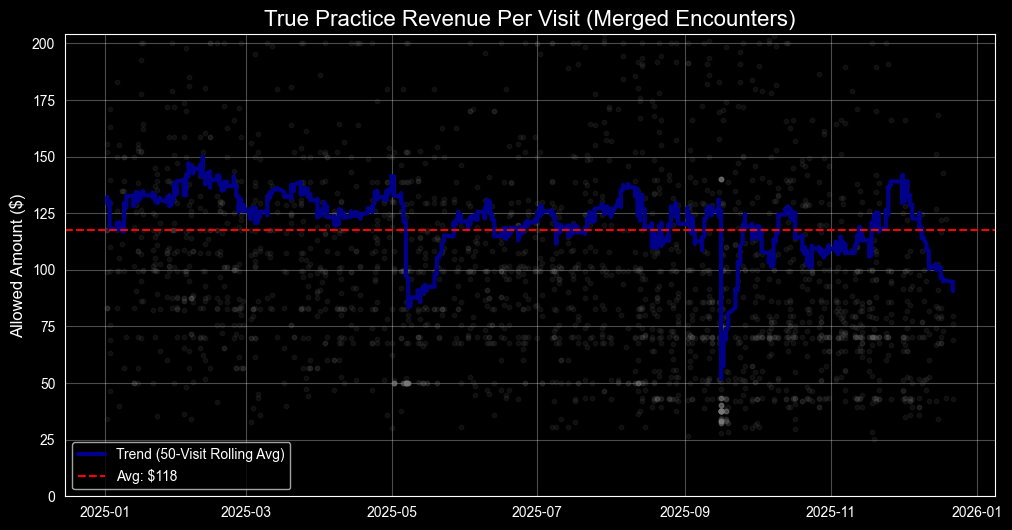

Practice Wide Average: $117.68
Chart Scale Set to: $0 - $454 (Hides top 2% outliers for readability)


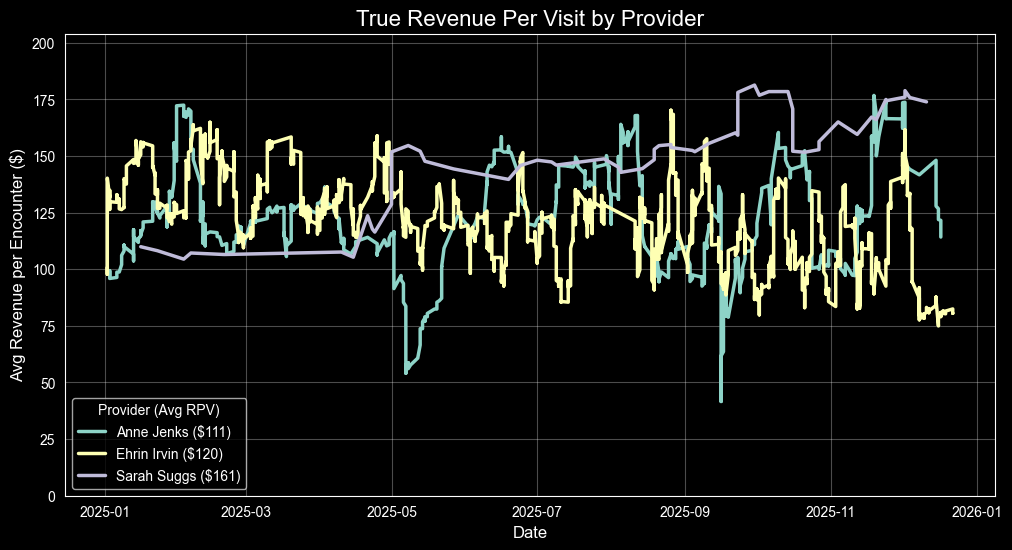

In [ ]:
# ==========================================
# FINAL RPV TREND REPORT (Merged Encounters)
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURATION ---
START_DATE = '2025-01-01'
END_DATE   = '2025-12-31'
MIN_VISIT_VALUE = 25  # Filter out low-value admin visits (nurse visits, etc)
PENDING_DAYS = 30     # Filter out recent claims waiting for insurance

if 'charges' not in locals():
    print("Please run the Data Loading cell first.")
else:
    # 1. SETUP & CLEANING
    # -------------------
    # Clean Provider Names
    charges['Rendering Provider'] = charges['Rendering Provider'].astype(str).str.upper().str.strip()
    provider_map = {
        'EHRIN IRVIN, FNP': 'Ehrin Irvin',
        'ANNE JENKS, APRN': 'Anne Jenks',
        'SARAH SUGGS, NP':  'Sarah Suggs',
        'DAVID REDD, MD':   'Anne Jenks',
        'HEATHER MAYO, FNP': 'Heather Mayo'
    }
    charges['Normalized_Provider'] = charges['Rendering Provider'].map(provider_map).fillna('Other')
    target_providers = ['Anne Jenks', 'Ehrin Irvin', 'Sarah Suggs', 'Heather Mayo']

    # Financial Cleaning
    def clean_curr(x):
        if isinstance(x, str):
            x = x.replace('$', '').replace(',', '').strip()
            if '(' in x and ')' in x: x = '-' + x.replace('(', '').replace(')', '')
        return pd.to_numeric(x, errors='coerce')

    charges['Service Charge Amount'] = charges['Service Charge Amount'].apply(clean_curr).fillna(0)

    # Calculate Truth (Allowed = Billed - Writeoffs)
    adj_cols = ['Pri Ins Insurance Contract Adjustment', 'Sec Ins Insurance Contract Adjustment', 'Other Ins Insurance Contract Adjustment']
    charges['Total_Contract_Adj'] = 0
    for col in adj_cols:
        if col in charges.columns:
            charges['Total_Contract_Adj'] += charges[col].apply(clean_curr).fillna(0)

    charges['Allowed Amount'] = charges['Service Charge Amount'] - charges['Total_Contract_Adj']
    charges['Date Of Service'] = pd.to_datetime(charges['Date Of Service'])

    # 2. FILTERING
    # ------------
    df_trend = charges[
        (charges['Normalized_Provider'].isin(target_providers)) &
        (charges['Date Of Service'] >= pd.to_datetime(START_DATE)) &
        (charges['Date Of Service'] <= pd.to_datetime(END_DATE))
        ].copy()

    # REMOVE PENDING CLAIMS (<45 days old + No Adjudication)
    today = pd.Timestamp.now()
    if 'Pri Ins Adjudication Date' in df_trend.columns:
        df_trend['Pri Ins Adjudication Date'] = pd.to_datetime(df_trend['Pri Ins Adjudication Date'], errors='coerce')
        pending_mask = (df_trend['Date Of Service'] > (today - pd.Timedelta(days=PENDING_DAYS))) & (pd.isnull(df_trend['Pri Ins Adjudication Date']))
        df_trend = df_trend[~pending_mask]

    # 3. THE "MERGE" (Group by Patient + Date)
    # ---------------------------------------
    # This matches the logic that got us the correct $111-$156 numbers
    if 'Patient Name' not in df_trend.columns and 'Patient First Name' in df_trend.columns:
        df_trend['Patient Name'] = df_trend['Patient First Name'] + " " + df_trend['Patient Last Name']

    # Create the "Clean Encounter" Dataset
    encounters = df_trend.groupby(['Normalized_Provider', 'Date Of Service', 'Patient Name'])['Allowed Amount'].sum().reset_index()

    # Filter out noise (visits < $25)
    valid_encounters = encounters[encounters['Allowed Amount'] > MIN_VISIT_VALUE].copy()
    valid_encounters = valid_encounters.sort_values('Date Of Service')

    print(f"Generating Trends from {len(valid_encounters)} merged clinical encounters...")

    # 4. CHART 1: PRACTICE WIDE TREND
    # -------------------------------
    valid_encounters['Practice_Trend'] = valid_encounters['Allowed Amount'].rolling(window=100, min_periods=10).mean()
    avg_rpv = valid_encounters['Allowed Amount'].mean()

    # DYNAMIC SCALING LOGIC
    y_limit = valid_encounters['Allowed Amount'].quantile(0.98)

    plt.figure(figsize=(12, 6))
    plt.plot(valid_encounters['Date Of Service'], valid_encounters['Practice_Trend'], color='darkblue', linewidth=3, label='Trend (50-Visit Rolling Avg)')
    plt.scatter(valid_encounters['Date Of Service'], valid_encounters['Allowed Amount'], alpha=0.1, color='gray', s=10)

    plt.title(f'True Practice Revenue Per Visit (Merged Encounters)', fontsize=16)
    plt.ylabel('Allowed Amount ($)', fontsize=12)
    plt.axhline(avg_rpv, color='red', linestyle='--', label=f'Avg: ${avg_rpv:.0f}')

    # APPLY THE FIX
    plt.ylim(0, y_limit - 200)  # Set scale from 0 to the 98th percentile + padding

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Practice Wide Average: ${avg_rpv:,.2f}")
    print(f"Chart Scale Set to: $0 - ${y_limit + 50:.0f} (Hides top 2% outliers for readability)")

    # 5. CHART 2: PROVIDER TRENDS
    # ---------------------------
    plt.figure(figsize=(12, 6))

    for provider in target_providers:
        p_data = valid_encounters[valid_encounters['Normalized_Provider'] == provider].copy().sort_values('Date Of Service')

        if len(p_data) > 10:
            p_data['Smooth_Trend'] = p_data['Allowed Amount'].rolling(window=30, min_periods=5).mean()
            plt.plot(p_data['Date Of Service'], p_data['Smooth_Trend'], linewidth=2.5, label=f"{provider} (${p_data['Allowed Amount'].mean():.0f})")

    plt.title('True Revenue Per Visit by Provider', fontsize=16)
    plt.ylabel('Avg Revenue per Encounter ($)', fontsize=12)
    plt.xlabel('Date', fontsize=12)

    # APPLY THE SAME FIX
    plt.ylim(0, y_limit - 200)

    plt.legend(title='Provider (Avg RPV)')
    plt.grid(True, alpha=0.3)
    plt.show()


      TRUE REVENUE PER VISIT (Merged by Patient)
Total Raw Encounters:   2926
Excluded Zero/Low Visits: 317 (Likely denials or nurse visits <$25)
Valid Clinical Visits:  2609
------------------------------------------------------------
AVG BILLED PER VISIT:   $330.03
AVG ALLOWED PER VISIT:  $116.22
REALIZATION RATE:       35.2%
------------------------------------------------------------

PROVIDER BREAKDOWN:
      Provider  Visit Count  Avg Allowed (RPV)   Total Rev  Avg Billed
0   Anne Jenks          854            $109.27  $93,319.95     $304.14
1  Ehrin Irvin         1699            $118.54 $201,392.88     $341.08
2  Sarah Suggs           56            $151.69   $8,494.44     $389.41


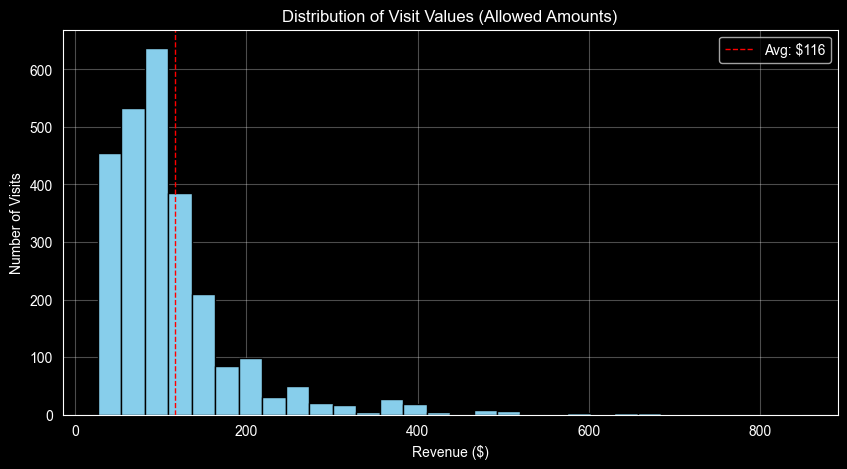

In [ ]:
# ==========================================
# RPV DEEP DIVE: PATIENT-LEVEL GROUPING (CORRECTED)
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
START_DATE = '2025-01-01'
END_DATE = '2025-12-31'
MIN_VISIT_VALUE = 25

if 'charges' not in locals():
    print("Please run the Data Loading cell first.")
else:
    # 1. CLEANING & SETUP
    # -------------------
    # Clean Provider Names
    charges['Rendering Provider'] = charges['Rendering Provider'].astype(str).str.upper().str.strip()
    provider_map = {
        'EHRIN IRVIN, FNP': 'Ehrin Irvin',
        'ANNE JENKS, APRN': 'Anne Jenks',
        'SARAH SUGGS, NP': 'Sarah Suggs',
        'DAVID REDD, MD': 'Anne Jenks',
        'HEATHER MAYO, FNP': 'Heather Mayo'
    }
    charges['Normalized_Provider'] = charges['Rendering Provider'].map(provider_map).fillna('Other')
    target_providers = ['Anne Jenks', 'Ehrin Irvin', 'Sarah Suggs', 'Heather Mayo']


    # Financial Cleaning
    def clean_curr(x):
        if isinstance(x, str):
            x = x.replace('$', '').replace(',', '').strip()
            if '(' in x and ')' in x: x = '-' + x.replace('(', '').replace(')', '')
        return pd.to_numeric(x, errors='coerce')


    # Apply Cleaning
    charges['Service Charge Amount'] = charges['Service Charge Amount'].apply(clean_curr).fillna(0)

    # Calculate Contract Adjustments
    adj_cols = ['Pri Ins Insurance Contract Adjustment', 'Sec Ins Insurance Contract Adjustment',
                'Other Ins Insurance Contract Adjustment']
    charges['Total_Contract_Adj'] = 0
    for col in adj_cols:
        if col in charges.columns:
            charges['Total_Contract_Adj'] += charges[col].apply(clean_curr).fillna(0)

    # Calculate Truth
    charges['Allowed Amount'] = charges['Service Charge Amount'] - charges['Total_Contract_Adj']
    charges['Date Of Service'] = pd.to_datetime(charges['Date Of Service'])

    # 2. FILTERING
    # ------------
    df_rpv = charges[
        (charges['Normalized_Provider'].isin(target_providers)) &
        (charges['Date Of Service'] >= pd.to_datetime(START_DATE)) &
        (charges['Date Of Service'] <= pd.to_datetime(END_DATE))
        ].copy()

    # REMOVE PENDING CLAIMS (The 45-day logic)
    today = pd.Timestamp.now()
    if 'Pri Ins Adjudication Date' in df_rpv.columns:
        df_rpv['Pri Ins Adjudication Date'] = pd.to_datetime(df_rpv['Pri Ins Adjudication Date'], errors='coerce')
        pending_mask = (df_rpv['Date Of Service'] > (today - pd.Timedelta(days=45))) & (
            pd.isnull(df_rpv['Pri Ins Adjudication Date']))
        df_rpv = df_rpv[~pending_mask]

    # --- SAFETY FIX: Ensure 'Claim ID' column exists ---
    if 'claim ID' in df_rpv.columns:
        df_rpv.rename(columns={'claim ID': 'Claim ID'}, inplace=True)

    # 3. THE "SUPER GROUPER" (Patient + Date)
    # ---------------------------------------
    if 'Patient Name' not in df_rpv.columns and 'Patient First Name' in df_rpv.columns:
        df_rpv['Patient Name'] = df_rpv['Patient First Name'] + " " + df_rpv['Patient Last Name']

    # Aggregation
    visits = df_rpv.groupby(['Normalized_Provider', 'Date Of Service', 'Patient Name']).agg({
        'Service Charge Amount': 'sum',  # Total Billed
        'Allowed Amount': 'sum',  # Total Allowed
        'Claim ID': 'nunique'  # Count how many claims were merged
    }).reset_index()

    # 4. EXCLUDE "NOISE" VISITS
    # -------------------------
    zero_visits = visits[visits['Allowed Amount'] <= 0]
    valid_visits = visits[visits['Allowed Amount'] > MIN_VISIT_VALUE].copy()  # Using $25 floor

    # 5. ANALYSIS
    # -----------
    avg_billed = valid_visits['Service Charge Amount'].mean()
    avg_allowed = valid_visits['Allowed Amount'].mean()
    realization = (avg_allowed / avg_billed * 100) if avg_billed > 0 else 0

    print("\n" + "=" * 60)
    print(f"      TRUE REVENUE PER VISIT (Merged by Patient)")
    print("=" * 60)
    print(f"Total Raw Encounters:   {len(visits)}")
    print(
        f"Excluded Zero/Low Visits: {len(visits) - len(valid_visits)} (Likely denials or nurse visits <${MIN_VISIT_VALUE})")
    print(f"Valid Clinical Visits:  {len(valid_visits)}")
    print("-" * 60)
    print(f"AVG BILLED PER VISIT:   ${avg_billed:,.2f}")
    print(f"AVG ALLOWED PER VISIT:  ${avg_allowed:,.2f}")
    print(f"REALIZATION RATE:       {realization:.1f}%")
    print("-" * 60)

    # 6. PROVIDER BREAKDOWN
    # ---------------------
    prov_stats = valid_visits.groupby('Normalized_Provider').agg({
        'Allowed Amount': ['count', 'mean', 'sum'],
        'Service Charge Amount': 'mean'
    }).reset_index()

    # Flatten columns
    prov_stats.columns = ['Provider', 'Visit Count', 'Avg Allowed (RPV)', 'Total Rev', 'Avg Billed']

    print("\nPROVIDER BREAKDOWN:")
    print(
        prov_stats.to_string(float_format=lambda x: f"${x:,.2f}" if x > 100 else f"{x:.0f}" if x > 10 else f"{x:.2f}"))

    # 7. HISTOGRAM
    plt.figure(figsize=(10, 5))
    plt.hist(valid_visits['Allowed Amount'], bins=30, color='skyblue', edgecolor='black')
    plt.axvline(avg_allowed, color='red', linestyle='dashed', linewidth=1, label=f'Avg: ${avg_allowed:.0f}')
    plt.title('Distribution of Visit Values (Allowed Amounts)')
    plt.xlabel('Revenue ($)')
    plt.ylabel('Number of Visits')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()